Project 2- Task 2: Classification with Logistic Regression

Description: Build a decision tree classifier to predict a categorical outcome (e.g., predict species of flowers).

Objectives

.Preprocess the data (e.g., handling categorical features,
feature scaling).

.Train and evaluate the logistic regression model.

.Use metrics such as accuracy, precision, recall, and the ROC curve for evaluation.

.Compare logistic regression with other classifiers like

.Random Forest or SVM.

.Tools: Python, scikit-learn, pandas, matplotlib.

PROCEDURE FOR EXECUTION



### Project 2 — Task 2: Classification

* 1. Load the dataset- from Scikit Learn -https://scikit-learn.org/1.4/modules/generated/sklearn.datasets.load_iris.html#**

 * 2. Inspect the data**

 * 3. Preprocess the data**

* 4. Train Logistic Regression**

* 5. Evaluate Logistic Regression**

* 6. Train Decision Tree Classifier**

  7. Evaluate Decision Tree**

 8. Train Random Forest Classifier**

 9. Evaluate Random Forest**

10. Compare the models**
11. Interpret the results**

12. Write the project report**



IMPORTING THE DATA SET - IRIS DATA FROM SCIKIT LEARNING

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


CHECKING THE STRUCTURE



In [5]:
df.shape



(150, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


CHECKING THE MISSING VALUE

In [7]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

To see the number of observations belonging to each species class.

In [8]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

To separate features from target

In [9]:
X = df.drop("species", axis=1)
y = df["species"]

X.shape, y.shape

((150, 4), (150,))

Train/Test Split

Using 80% for training and 20% for testing.

I wil also stratify=y?

This is because of the classification:

Class 0 → 50
Class 1 → 50
Class 2 → 50

stratify=y makes sure the same class proportions are maintained in both the training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

Standardize the features

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

fit only on the training data and transform both datasets:

fit_transform() → training data
transform() → testing data

#prevents data leakage from the test set into the training process.

In [14]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((120, 4), (30, 4))

Train Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in

Making Prediction and checking

In [16]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

Evaluation using; Accuracy,Precisiom_score, recall_score and F1

Accuracy → proportion of predictions that were correct.
Precision → how often predicted classes were actually correct.
Recall → how well the model identified the actual classes.
F1 Score → combines precision and recall.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average="weighted")
recall = recall_score(y_test, y_pred_log, average="weighted")
f1 = f1_score(y_test, y_pred_log, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333


Confusuion Matrix

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


| Actual → Predicted | Class 0 | Class 1 | Class 2 |
| ------------------ | ------: | ------: | ------: |
| **Class 0**        |      10 |       0 |       0 |
| **Class 1**        |       0 |       9 |       1 |
| **Class 2**        |       0 |       1 |       9 |


Class 0: 10/10 correctly classified.
Class 1: 9/10 correctly classified; 1 was predicted as Class 2.
Class 2: 9/10 correctly classified; 1 was predicted as Class 1.
Total correct = 28/30, which gives our 93.33% accuracy.

So the model's errors are only between Class 1 and Class 2.

Visual Display

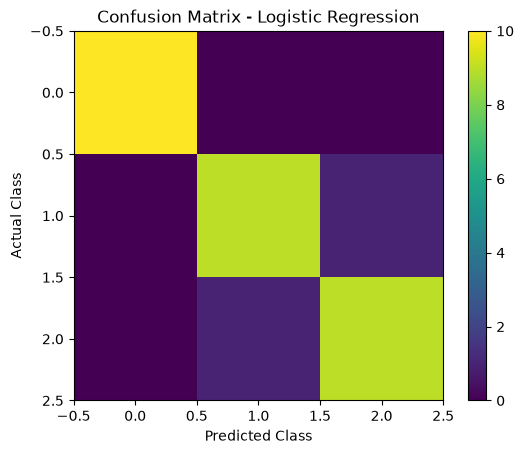

In [19]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()
plt.show()

ROC/AUC

In [22]:
#First get the model's predicted probabilities:

y_prob_log = log_model.predict_proba(X_test_scaled)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob_log,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)



ROC-AUC: 0.9966666666666666


Plotting the ROC Curve

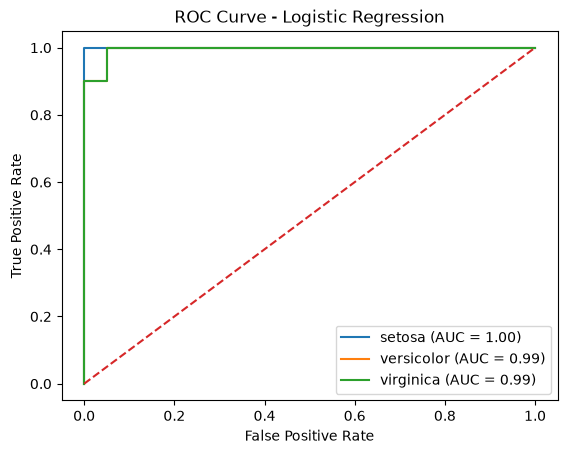

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert the test labels to a binary format for each class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Plot ROC curve for each class
for i, class_name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_log[:, i])
    roc_auc_class = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc_class:.2f})"
    )

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Train the Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

tree_clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

Making Prediction

In [25]:
y_pred_tree = tree_clf.predict(X_test)

Checking Accuracy

In [26]:
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.9333333333333333


Evaluaating the Decison Tree

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_tree = precision_score(y_test, y_pred_tree, average="weighted")
recall_tree = recall_score(y_test, y_pred_tree, average="weighted")
f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1 Score:", f1_tree)

Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333


Getting it's predicted probabilities and ROC-AUC

In [28]:
y_prob_tree = tree_clf.predict_proba(X_test)

roc_auc_tree = roc_auc_score(
    y_test,
    y_prob_tree,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc_tree)

ROC-AUC: 0.95


| Metric    | Logistic Regression | Decision Tree |
| --------- | ------------------: | ------------: |
| Accuracy  |              0.9333 |        0.9333 |
| Precision |              0.9333 |        0.9333 |
| Recall    |              0.9333 |        0.9333 |
| F1 Score  |              0.9333 |        0.9333 |
| ROC-AUC   |              0.9967 |        0.9500 |


Train Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Predicting and Checking the accuracy

In [30]:
y_pred_rf = rf_clf.predict(X_test)

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9


Evaluate Random Forest

In [32]:
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

Precision: 0.9023569023569024
Recall: 0.9
F1 Score: 0.8997493734335839


In [33]:
y_prob_rf = rf_clf.predict_proba(X_test)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.9866666666666666


Complete Result
| Metric    | Logistic Regression | Decision Tree | Random Forest |
| --------- | ------------------: | ------------: | ------------: |
| Accuracy  |              93.33% |        93.33% |        90.00% |
| Precision |              93.33% |        93.33% |        90.24% |
| Recall    |              93.33% |        93.33% |        90.00% |
| F1 Score  |              93.33% |        93.33% |        89.97% |
| ROC-AUC   |              99.67% |        95.00% |        98.67% |


Model Comparison

In [34]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_tree,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.996667
1,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.950000
2,Random Forest,0.900000,0.902357,0.900000,0.899749,0.986667


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>Accuracy</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1 Score</th>
      <th>ROC-AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Logistic Regression</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.996667</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Decision Tree</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.933333</td>
      <td>0.950000</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Random Forest</td>
      <td>0.900000</td>
      <td>0.902357</td>
      <td>0.900000</td>
      <td>0.899749</td>
      <td>0.986667</td>
    </tr>
  </tbody>
</table>
</div>

Comparsion Visualization

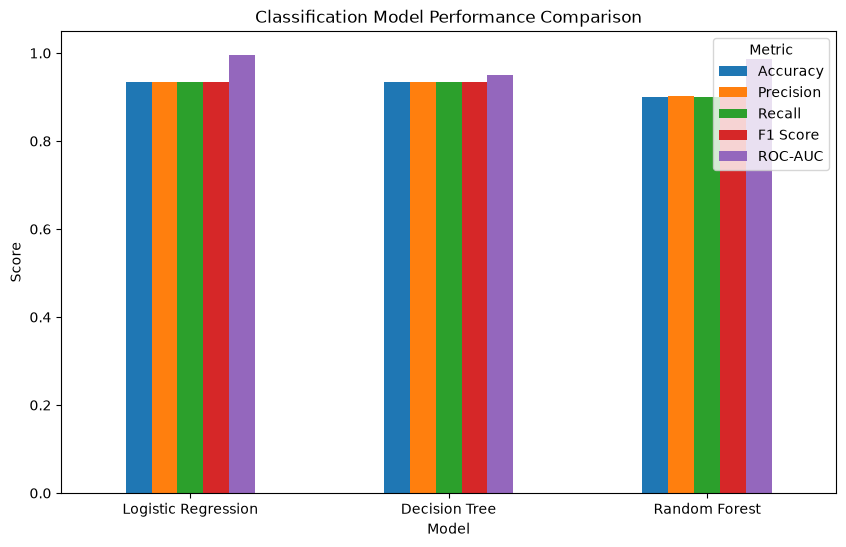

In [35]:
import matplotlib.pyplot as plt

results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Metric")
plt.show()

PROJECT SUMMARY

# Project 2 — Task 2: Classification with Logistic Regression

## 1. Objective

The objective of this task was to build and evaluate classification models for predicting the species of iris flowers. The task involved preprocessing the dataset, training a Logistic Regression model, evaluating its performance using classification metrics and an ROC curve, and comparing its performance with Decision Tree and Random Forest classifiers.

## 2. Dataset

The Iris dataset from `scikit-learn`-https://scikit-learn.org/1.4/modules/generated/sklearn.datasets.load_iris.html# was used for this task.

The dataset contains:

* **150 observations**
* **4 numerical features**

  * Sepal length
  * Sepal width
  * Petal length
  * Petal width
* **3 target classes**, representing three iris species
* **50 observations per class**
* **No missing values**

The target variable was encoded as:

* `0`
* `1`
* `2`

The classes were evenly distributed, making the dataset balanced.

## 3. Data Preprocessing

The dataset was first separated into features (`X`) and the target variable (`y`).

The data was divided into:

* **80% training data:** 120 observations
* **20% testing data:** 30 observations

A stratified train-test split was used to preserve the class distribution in both datasets.

Feature scaling was performed using `StandardScaler` for Logistic Regression. The scaler was fitted only on the training data and then applied to both the training and testing data.

Decision Tree and Random Forest models were trained using the original numerical features because tree-based models do not require feature scaling.

## 4. Models Used

Three classification models were trained and evaluated:

1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**

Logistic Regression was the primary model for this task, while the Decision Tree and Random Forest were used for comparison.

## 5. Evaluation Metrics

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC

A confusion matrix and ROC curve were also generated for the Logistic Regression model.

## 6. Logistic Regression Results

The Logistic Regression model achieved:

| Metric    |  Score |
| --------- | -----: |
| Accuracy  | 0.9333 |
| Precision | 0.9333 |
| Recall    | 0.9333 |
| F1 Score  | 0.9333 |
| ROC-AUC   | 0.9967 |

The model correctly classified **28 out of the 30 test observations**.

The confusion matrix showed that all observations belonging to Class 0 were correctly classified. The two classification errors occurred between Class 1 and Class 2.

The ROC curve produced a very high ROC-AUC value of **0.9967**, indicating strong class-separation performance on this test set.

## 7. Model Comparison

The three models produced the following results:

| Model               | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| ------------------- | -------: | --------: | -----: | -------: | ------: |
| Logistic Regression |   0.9333 |    0.9333 | 0.9333 |   0.9333 |  0.9967 |
| Decision Tree       |   0.9333 |    0.9333 | 0.9333 |   0.9333 |  0.9500 |
| Random Forest       |   0.9000 |    0.9024 | 0.9000 |   0.8997 |  0.9867 |

On this particular test split, Logistic Regression and Decision Tree achieved the same accuracy of **93.33%**.

Random Forest achieved an accuracy of **90.00%**.

The Logistic Regression model produced the highest ROC-AUC among the three models in this experiment, with a value of **0.9967**.

## 8. Interpretation

The results show that all three models were able to classify the Iris species effectively on the test data.

Logistic Regression performed strongly across all evaluation metrics. Its confusion matrix showed that the classification errors were limited to confusion between two of the three classes.

The Decision Tree achieved the same accuracy, precision, recall, and F1 score as Logistic Regression on the test set, although its ROC-AUC was lower.

The Random Forest model achieved a lower accuracy on this particular test split, although its ROC-AUC remained high at approximately **0.9867**.

These results demonstrate that different classification algorithms can produce different performance patterns even when trained on the same dataset.

## 9. Conclusion

This task successfully demonstrated the process of building and evaluating classification models using Python and scikit-learn.

The Iris dataset was inspected and preprocessed, Logistic Regression was trained and evaluated, and additional Decision Tree and Random Forest models were used for comparison.

On the selected test split, Logistic Regression and Decision Tree both achieved **93.33% accuracy**, while Random Forest achieved **90.00% accuracy**. Logistic Regression also produced a ROC-AUC of **0.9967**.

The experiment shows how accuracy, precision, recall, F1 score, ROC-AUC, confusion matrices, and ROC curves can be used together to evaluate classification models rather than relying on a single metric.

> **Note:** The reported results are based on a single 80/20 train-test split with 30 test observations. Therefore, they describe the performance observed in this experiment and should not be interpreted as a guarantee of performance on every new dataset.
